# Explain the IDS model decisions

This optional stage explains **why** the trained Random Forests make their
decisions. It uses three methods:

1. **Built-in importance** - the features that the trees use most often.
2. **Permutation importance** - the score that the model loses when one feature is shuffled.
3. **SHAP** - how each feature moves one single prediction up or down.

The notebook explains binary intrusion detection (benign or attack) and attack-type classification (the attack
type).

**Note on feature values.** The saved data is standardized: every value is
the number of standard deviations from the training mean. A value of `2.5`
means "2.5 standard deviations above average", not "2.5 bytes". The cells
below use the saved scaler to show the original network values as well.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURE_FILE = PROJECT_ROOT / "artifacts/feature_selection/selected_features.json"
TEST_FILE = PROJECT_ROOT / "dataset/processed/test.parquet"
SCALER_FILE = PROJECT_ROOT / "dataset/processed/standard_scaler.joblib"
BINARY_MODEL_FILE = PROJECT_ROOT / "artifacts/models/random_forest.joblib"
ATTACK_MODEL_FILE = PROJECT_ROOT / "artifacts/attack_type_model/random_forest_attack_type.joblib"
OUTPUT_FOLDER = PROJECT_ROOT / "artifacts/explainability"

required_files = [FEATURE_FILE, TEST_FILE, BINARY_MODEL_FILE, ATTACK_MODEL_FILE]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

features = json.loads(FEATURE_FILE.read_text(encoding="utf-8"))["selected_features"]
test = pd.read_parquet(
    TEST_FILE, columns=features + ["is_attack", "attack_label", "attack_category"]
)
binary_model = joblib.load(BINARY_MODEL_FILE)
attack_model = joblib.load(ATTACK_MODEL_FILE)
binary_model.n_jobs = 1
attack_model.n_jobs = 1
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"SHAP version:          {shap.__version__}")
print(f"Test rows:             {len(test):,}")
print(f"Selected features:     {len(features)}")
print(f"Binary classes:        {list(binary_model.classes_)}")
print(f"Attack-type classes:   {len(attack_model.classes_)}")
assert binary_model.n_features_in_ == len(features)
assert attack_model.n_features_in_ == len(features)

SHAP version:          0.51.0
Test rows:             499,596
Selected features:     20
Binary classes:        [np.int8(0), np.int8(1)]
Attack-type classes:   12


In [2]:
def original_values(scaled_rows):
    if not SCALER_FILE.exists():
        return None
    scaler = joblib.load(SCALER_FILE)
    all_columns = list(scaler.feature_names_in_)
    full = pd.DataFrame(0.0, index=scaled_rows.index, columns=all_columns)
    full[scaled_rows.columns] = scaled_rows
    restored = pd.DataFrame(
        scaler.inverse_transform(full), index=scaled_rows.index, columns=all_columns
    )
    return restored[scaled_rows.columns]

## 1. Built-in Random Forest importance

Binary Intrusion Detection: built-in feature importance


,importance
Average Packet Size,0.12020
Packet Length Variance,0.11610
Bwd Packet Length Std,0.10306
Packet Length Std,0.09984
Destination Port,0.08390
Subflow Bwd Bytes,0.06770
Avg Bwd Segment Size,0.06732
Init_Win_bytes_backward,0.05368
Init_Win_bytes_forward,0.04243
Avg Fwd Segment Size,0.04221


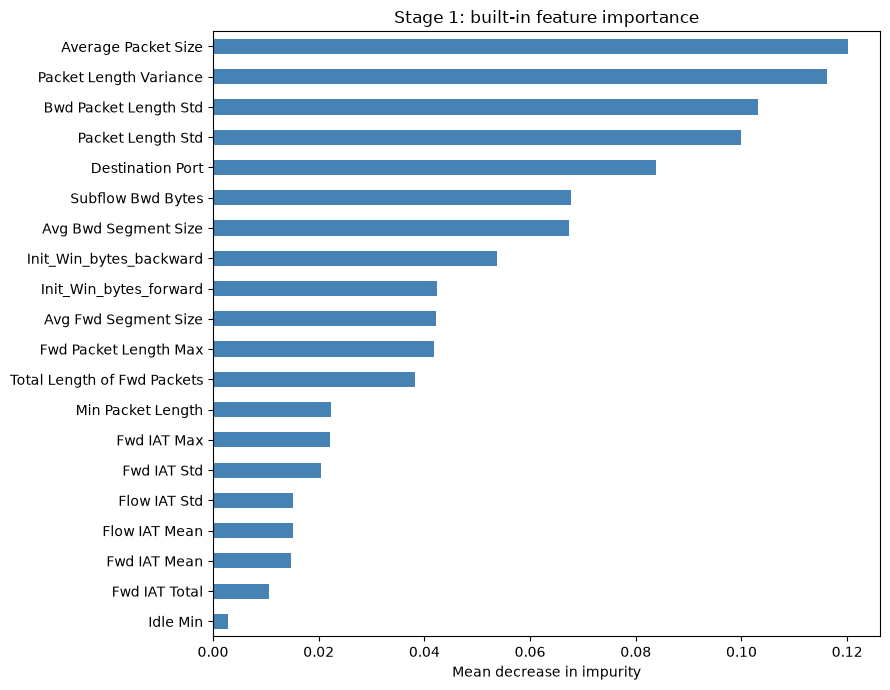

Attack-Type Classification: built-in feature importance


,importance
Destination Port,0.12286
Init_Win_bytes_backward,0.08633
Fwd Packet Length Max,0.07741
Avg Bwd Segment Size,0.06626
Subflow Bwd Bytes,0.05931
Average Packet Size,0.05384
Fwd IAT Total,0.05254
Flow IAT Mean,0.05122
Fwd IAT Mean,0.04570
Total Length of Fwd Packets,0.04550


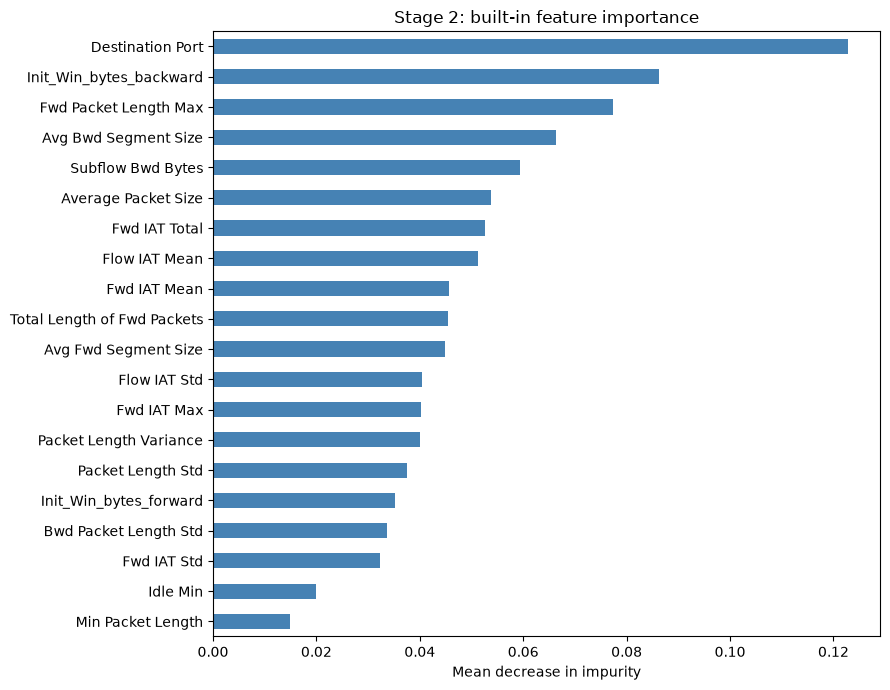

In [3]:
def show_tree_importance(model, title, file_name):
    importance = pd.Series(
        model.feature_importances_, index=features, name="importance"
    ).sort_values(ascending=False)
    print(title)
    display(importance.to_frame().round(5))

    figure, axis = plt.subplots(figsize=(9, 7))
    importance.sort_values().plot.barh(color="steelblue", ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Mean decrease in impurity")
    figure.tight_layout()
    figure.savefig(OUTPUT_FOLDER / file_name, dpi=150)
    plt.show()
    return importance


binary_tree_importance = show_tree_importance(
    binary_model, "Binary Intrusion Detection: built-in feature importance", "binary_tree_importance.png"
)
attack_tree_importance = show_tree_importance(
    attack_model, "Attack-Type Classification: built-in feature importance", "attack_tree_importance.png"
)

## 2. Permutation importance

Binary Intrusion Detection: permutation importance


,feature,mean_score_decrease,standard_deviation
12,Init_Win_bytes_backward,0.37657,0.00089
5,Destination Port,0.19554,0.01367
8,Subflow Bwd Bytes,0.08967,0.00620
16,Init_Win_bytes_forward,0.08958,0.00285
18,Flow IAT Mean,0.07227,0.00404
4,Average Packet Size,0.05916,0.00334
3,Bwd Packet Length Std,0.01251,0.00027
7,Fwd IAT Std,0.00714,0.00152
2,Avg Bwd Segment Size,0.00115,0.00047
17,Fwd IAT Mean,0.00115,0.00080


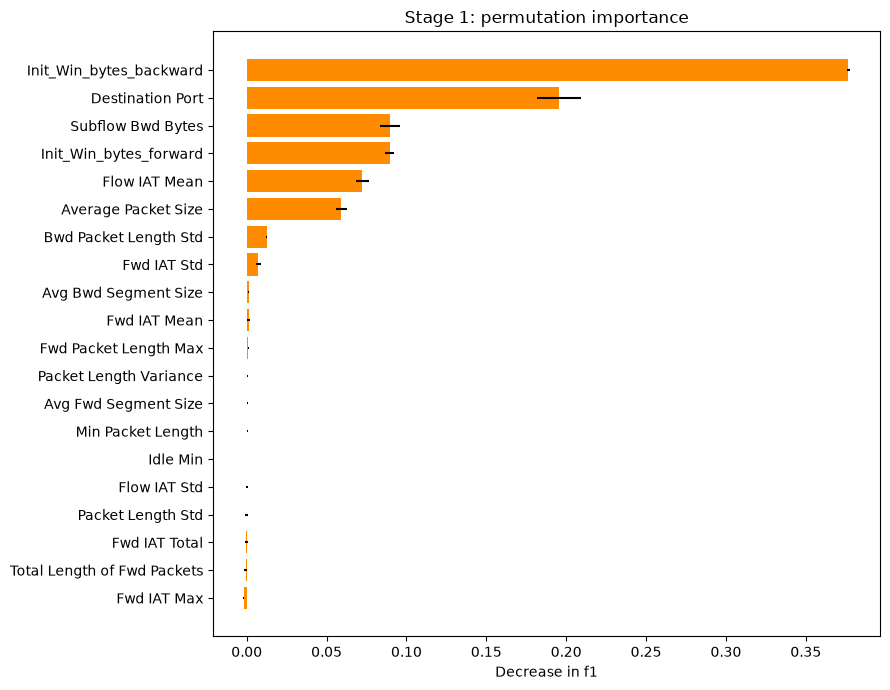

Attack-Type Classification: permutation importance


,feature,mean_score_decrease,standard_deviation
5,Destination Port,0.07717,0.00517
12,Init_Win_bytes_backward,0.04573,0.00775
16,Init_Win_bytes_forward,0.00554,0.00219
9,Flow IAT Std,0.00397,0.00076
7,Fwd IAT Std,0.00259,0.00000
1,Packet Length Std,0.00152,0.00000
18,Flow IAT Mean,0.00135,0.00095
0,Packet Length Variance,0.00122,0.00071
13,Fwd IAT Total,0.00101,0.00071
10,Fwd Packet Length Max,0.00051,0.00071


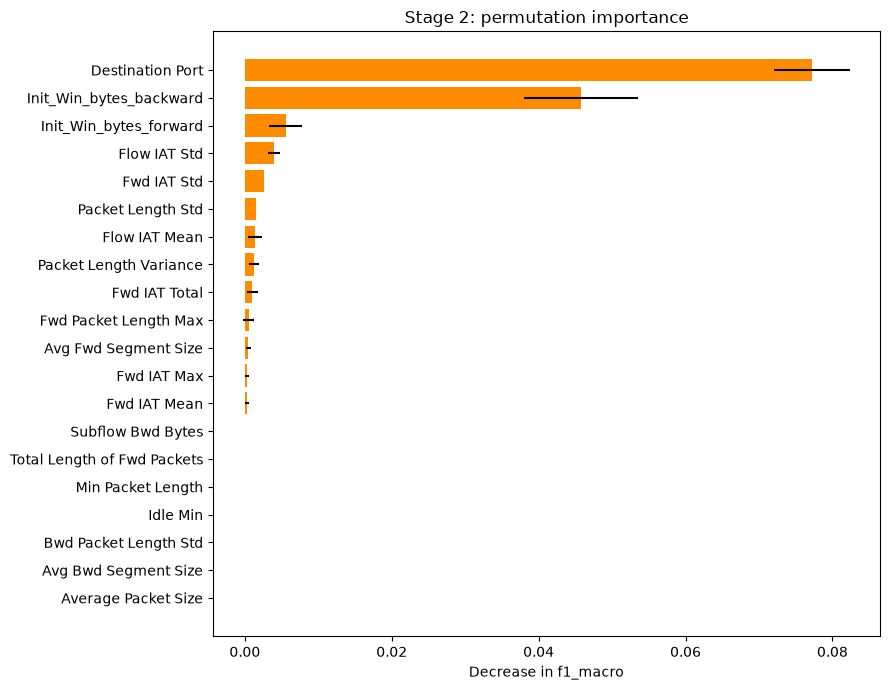

In [4]:
def show_permutation_importance(model, x, y, scoring, title, file_name):
    result = permutation_importance(
        model, x, y, scoring=scoring, n_repeats=3,
        random_state=RANDOM_STATE, n_jobs=1,
    )
    importance = pd.DataFrame({
        "feature": features,
        "mean_score_decrease": result.importances_mean,
        "standard_deviation": result.importances_std,
    }).sort_values("mean_score_decrease", ascending=False)

    print(title)
    display(importance.round(5))
    plot_data = importance.sort_values("mean_score_decrease")
    figure, axis = plt.subplots(figsize=(9, 7))
    axis.barh(
        plot_data["feature"], plot_data["mean_score_decrease"],
        xerr=plot_data["standard_deviation"], color="darkorange",
    )
    axis.set_xlabel(f"Decrease in {scoring}")
    axis.set_title(title)
    figure.tight_layout()
    figure.savefig(OUTPUT_FOLDER / file_name, dpi=150)
    plt.show()
    return importance


binary_sample = test.sample(5000, random_state=RANDOM_STATE)
binary_permutation = show_permutation_importance(
    binary_model, binary_sample[features], binary_sample["is_attack"],
    scoring="f1", title="Binary Intrusion Detection: permutation importance",
    file_name="binary_permutation_importance.png",
)

attack_rows = test[test["is_attack"] == 1]
attack_sample = attack_rows.sample(5000, random_state=RANDOM_STATE)
attack_permutation = show_permutation_importance(
    attack_model, attack_sample[features], attack_sample["attack_category"].astype(str),
    scoring="f1_macro", title="Attack-Type Classification: permutation importance",
    file_name="attack_permutation_importance.png",
)

## 3. Compare the two importance methods

In [5]:
comparison = pd.DataFrame({
    "tree_importance_rank": binary_tree_importance.rank(ascending=False).astype(int),
    "permutation_rank": binary_permutation.set_index("feature")["mean_score_decrease"]
        .rank(ascending=False).astype(int),
})
comparison["rank_difference"] = (
    comparison["tree_importance_rank"] - comparison["permutation_rank"]
).abs()
display(comparison.sort_values("tree_importance_rank"))

,tree_importance_rank,permutation_rank,rank_difference
Average Packet Size,1,6,5
Packet Length Variance,2,12,10
Bwd Packet Length Std,3,7,4
Packet Length Std,4,17,13
Destination Port,5,2,3
Subflow Bwd Bytes,6,3,3
Avg Bwd Segment Size,7,9,2
Init_Win_bytes_backward,8,1,7
Init_Win_bytes_forward,9,4,5
Avg Fwd Segment Size,10,13,3


## 4. Global SHAP explanation for attack detection

Binary SHAP dimensions: (1000, 20, 2)
(rows, features, classes)


,mean_absolute_shap
Bwd Packet Length Std,0.057810
Init_Win_bytes_backward,0.055405
Destination Port,0.055151
Average Packet Size,0.051766
Subflow Bwd Bytes,0.047835
Avg Bwd Segment Size,0.042510
Packet Length Variance,0.040360
Packet Length Std,0.036347
Init_Win_bytes_forward,0.023397
Fwd Packet Length Max,0.022050


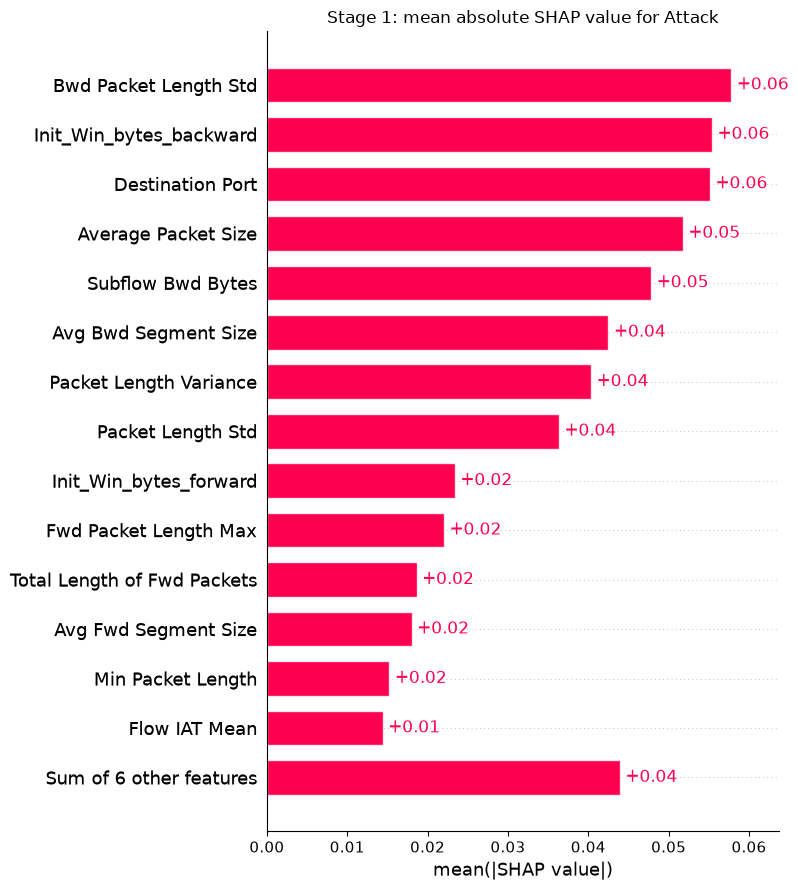

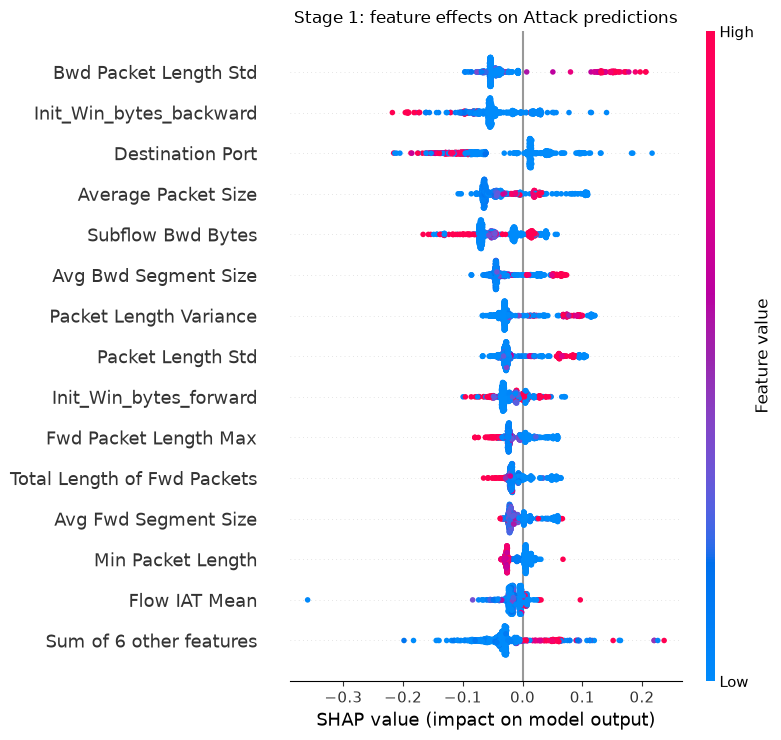

In [7]:
binary_shap_sample = test.sample(1000, random_state=RANDOM_STATE)[features]
binary_explainer = shap.TreeExplainer(binary_model)
binary_explanation = binary_explainer(binary_shap_sample)
attack_class_index = list(binary_model.classes_).index(1)
binary_attack_shap = binary_explanation[:, :, attack_class_index]

print(f"Binary SHAP dimensions: {binary_explanation.values.shape}")
print("(rows, features, classes)")
binary_shap_importance = pd.Series(
    np.abs(binary_attack_shap.values).mean(axis=0),
    index=features, name="mean_absolute_shap",
).sort_values(ascending=False)
display(binary_shap_importance.to_frame().round(6))

shap.plots.bar(binary_attack_shap, max_display=15, show=False)
plt.title("Binary Intrusion Detection: mean absolute SHAP value for Attack")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "binary_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(binary_attack_shap, max_display=15, show=False)
plt.title("Binary Intrusion Detection: feature effects on Attack predictions")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "binary_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Explain one binary decision

Binary decision being explained
  Test row position:   64
  Actual label:        BENIGN
  Actual is_attack:    0
  Predicted is_attack: 1
  Attack probability:  0.629450


,standardized value,original value
Packet Length Variance,-0.3159,1.780000e-02
Packet Length Std,-0.5020,0.000000e+00
Avg Bwd Segment Size,-0.5403,-0.000000e+00
Bwd Packet Length Std,-0.4296,-0.000000e+00
Average Packet Size,-0.6165,0.000000e+00
Destination Port,-0.4557,8.000000e+01
Fwd IAT Max,-0.1876,5.380740e+06
Fwd IAT Std,0.0089,3.794007e+06
Subflow Bwd Bytes,-0.0075,-1.500000e-03
Flow IAT Std,-0.0244,3.102192e+06


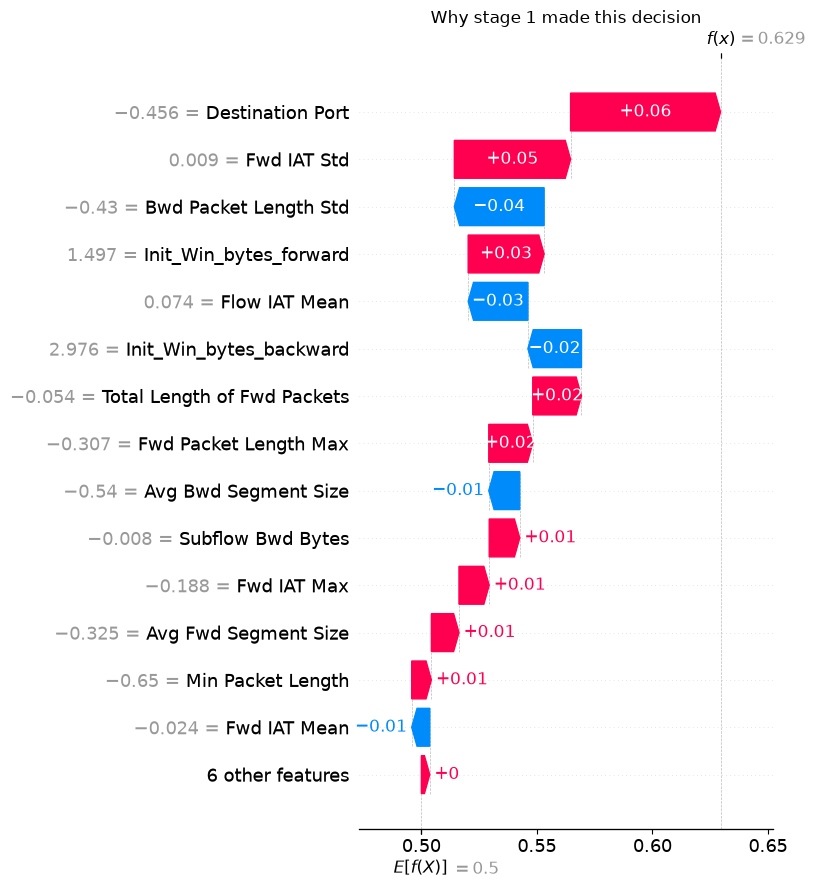

In [8]:
binary_probabilities = binary_model.predict_proba(test[features])[:, attack_class_index]
binary_predictions = (binary_probabilities >= 0.5).astype("int8")
binary_errors = np.flatnonzero(binary_predictions != test["is_attack"].to_numpy())
example_position = int(binary_errors[0]) if len(binary_errors) else 0
example_x = test[features].iloc[[example_position]]
example_explanation = binary_explainer(example_x)[:, :, attack_class_index]

print("Binary decision being explained")
print(f"  Test row position:   {example_position}")
print(f"  Actual label:        {test.iloc[example_position]['attack_label']}")
print(f"  Actual is_attack:    {int(test.iloc[example_position].is_attack)}")
print(f"  Predicted is_attack: {int(binary_predictions[example_position])}")
print(f"  Attack probability:  {binary_probabilities[example_position]:.6f}")

value_table = example_x.transpose()
value_table.columns = ["standardized value"]
restored = original_values(example_x)
if restored is not None:
    value_table["original value"] = restored.transpose().iloc[:, 0]
display(value_table.round(4))

shap.plots.waterfall(example_explanation[0], max_display=15, show=False)
plt.title("Why binary intrusion detection made this decision")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "binary_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Global SHAP explanation for attack types

Attack-type SHAP dimensions: (1000, 20, 12)
(rows, features, attack classes)


,mean_absolute_shap
Destination Port,0.025491
Fwd Packet Length Max,0.016611
Init_Win_bytes_backward,0.014737
Avg Bwd Segment Size,0.014461
Bwd Packet Length Std,0.013215
Subflow Bwd Bytes,0.013151
Packet Length Variance,0.010651
Avg Fwd Segment Size,0.010291
Flow IAT Mean,0.009553
Packet Length Std,0.009409


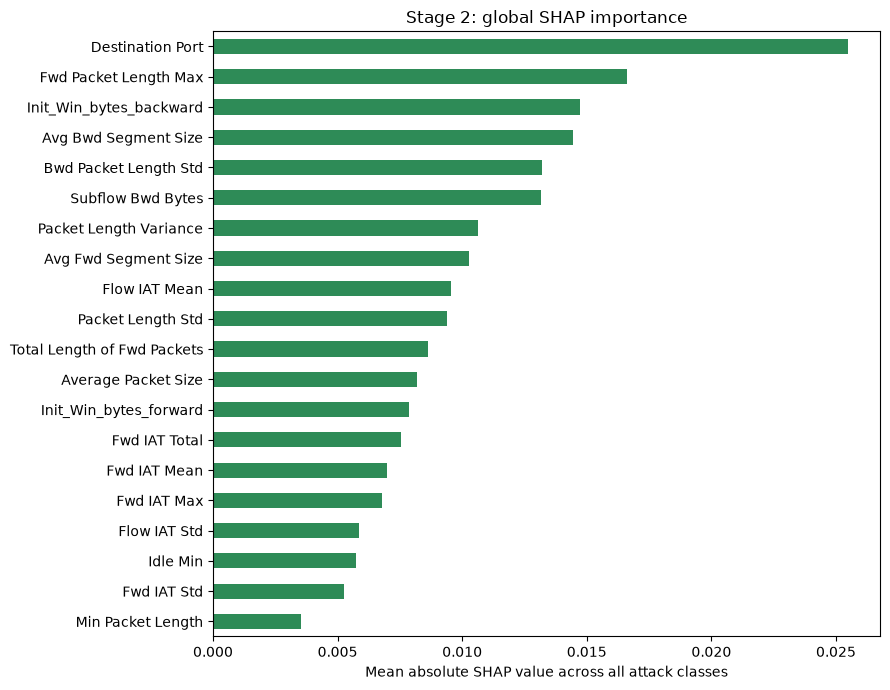

In [9]:
attack_shap_sample = attack_rows.sample(1000, random_state=RANDOM_STATE)[features]
attack_explainer = shap.TreeExplainer(attack_model)
attack_explanation = attack_explainer(attack_shap_sample)

print(f"Attack-type SHAP dimensions: {attack_explanation.values.shape}")
print("(rows, features, attack classes)")
attack_shap_importance = pd.Series(
    np.abs(attack_explanation.values).mean(axis=(0, 2)),
    index=features, name="mean_absolute_shap",
).sort_values(ascending=False)
display(attack_shap_importance.to_frame().round(6))

figure, axis = plt.subplots(figsize=(9, 7))
attack_shap_importance.sort_values().plot.barh(color="seagreen", ax=axis)
axis.set_xlabel("Mean absolute SHAP value across all attack classes")
axis.set_title("Attack-Type Classification: global SHAP importance")
figure.tight_layout()
figure.savefig(OUTPUT_FOLDER / "attack_shap_bar.png", dpi=150)
plt.show()

## 7. Explain one attack-type decision

Attack-type decision being explained
  Attack row position: 1160
  Actual attack:       DoS Slowhttptest
  Predicted attack:    DoS slowloris
  Model confidence:    0.999982


,standardized value,original value
Packet Length Variance,-0.3159,1.780000e-02
Packet Length Std,-0.5020,0.000000e+00
Avg Bwd Segment Size,-0.5403,-0.000000e+00
Bwd Packet Length Std,-0.4296,-0.000000e+00
Average Packet Size,-0.6165,0.000000e+00
Destination Port,-0.4557,8.000000e+01
Fwd IAT Max,-0.3181,2.003988e+06
Fwd IAT Std,-0.2939,7.108392e+05
Subflow Bwd Bytes,-0.0075,-1.500000e-03
Flow IAT Std,-0.3060,7.108391e+05


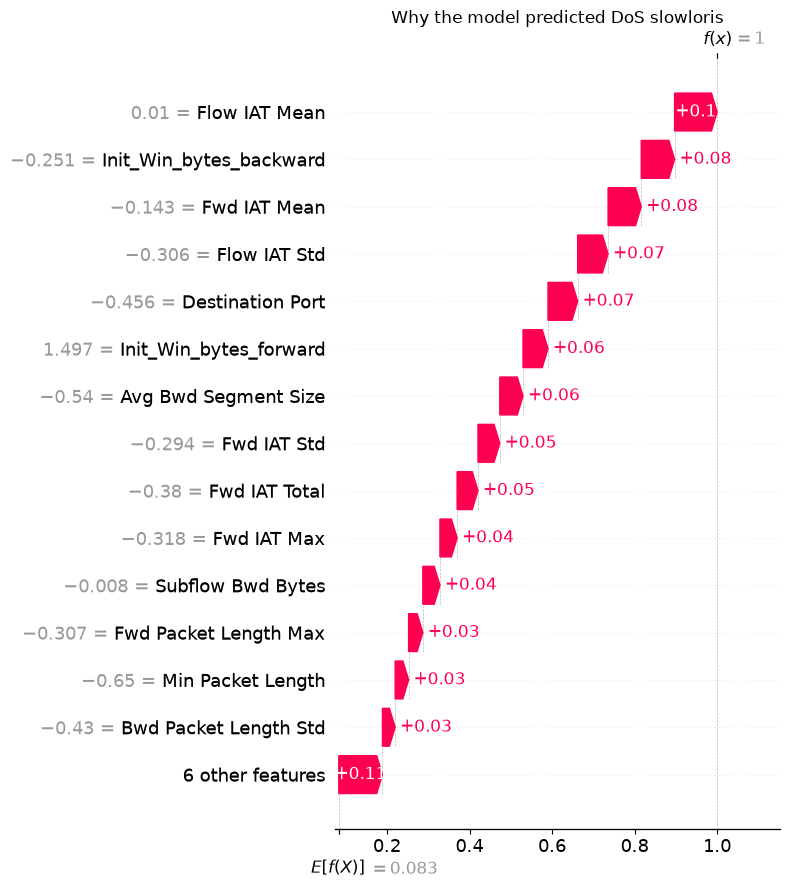

In [10]:
attack_predictions = attack_model.predict(attack_rows[features])
attack_truth = attack_rows["attack_category"].astype(str).to_numpy()
attack_errors = np.flatnonzero(attack_predictions != attack_truth)
attack_position = int(attack_errors[0]) if len(attack_errors) else 0
attack_example_x = attack_rows[features].iloc[[attack_position]]
predicted_attack = attack_predictions[attack_position]
predicted_class_index = list(attack_model.classes_).index(predicted_attack)
attack_probability = attack_model.predict_proba(attack_example_x)[0, predicted_class_index]
attack_example_explanation = attack_explainer(attack_example_x)[:, :, predicted_class_index]

print("Attack-type decision being explained")
print(f"  Attack row position: {attack_position}")
print(f"  Actual attack:       {attack_truth[attack_position]}")
print(f"  Predicted attack:    {predicted_attack}")
print(f"  Model confidence:    {attack_probability:.6f}")

value_table = attack_example_x.transpose()
value_table.columns = ["standardized value"]
restored = original_values(attack_example_x)
if restored is not None:
    value_table["original value"] = restored.transpose().iloc[:, 0]
display(value_table.round(4))

shap.plots.waterfall(attack_example_explanation[0], max_display=15, show=False)
plt.title(f"Why the model predicted {predicted_attack}")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "attack_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save the importance tables

In [12]:
importance_table = pd.DataFrame({
    "binary_tree_importance": binary_tree_importance,
    "binary_permutation": binary_permutation.set_index("feature")["mean_score_decrease"],
    "binary_mean_absolute_shap": binary_shap_importance,
    "attack_tree_importance": attack_tree_importance,
    "attack_permutation": attack_permutation.set_index("feature")["mean_score_decrease"],
    "attack_mean_absolute_shap": attack_shap_importance,
}).sort_values("binary_tree_importance", ascending=False)
importance_table.index.name = "feature"
importance_table.to_csv(OUTPUT_FOLDER / "feature_importance_summary.csv")
display(importance_table.round(5))
# print(f"Saved in {OUTPUT_FOLDER}")

,binary_tree_importance,binary_permutation,binary_mean_absolute_shap,attack_tree_importance,attack_permutation,attack_mean_absolute_shap
feature,,,,,,
Average Packet Size,0.12020,0.05916,0.05177,0.05384,0.00000,0.00819
Packet Length Variance,0.11610,0.00041,0.04036,0.04000,0.00122,0.01065
Bwd Packet Length Std,0.10306,0.01251,0.05781,0.03360,0.00000,0.01322
Packet Length Std,0.09984,0.00002,0.03635,0.03745,0.00152,0.00941
Destination Port,0.08390,0.19554,0.05515,0.12286,0.07717,0.02549
Subflow Bwd Bytes,0.06770,0.08967,0.04783,0.05931,0.00000,0.01315
Avg Bwd Segment Size,0.06732,0.00115,0.04251,0.06626,0.00000,0.01446
Init_Win_bytes_backward,0.05368,0.37657,0.05540,0.08633,0.04573,0.01474
Init_Win_bytes_forward,0.04243,0.08958,0.02340,0.03520,0.00554,0.00787
